<a href="https://colab.research.google.com/github/cedizen/saas_churn_project/blob/main/saas_project_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SaaS churn analysis and prediction**

## **Project overview**

In this project, I worked on a simulated SaaS business case to understand and predict customer churn at the account level.

The goal was not only to train a machine learning model, but also to go through a realistic data analyst workflow:
- inspect and clean multiple datasets,
- define the right level of analysis,
- create business-oriented features,
- compare different models,
- and translate the results into practical business insights.

This project is designed as a portfolio case study for a junior data analyst role, with a focus on structured thinking, feature engineering, and clear interpretation.

## **Business problem**

For a SaaS company, churn is an important issue because losing customers directly affects recurring revenue and growth.

The business question in this case is:

**Can we identify which customer accounts are more likely to churn, and which characteristics seem to be associated with that risk?**

If this type of model was used in a real company, it could help Customer Success or Marketing teams:
- spot at-risk accounts earlier,
- prioritize retention actions,
- and better understand which customer segments may need more attention.

## **Data used**

The analysis is based on several datasets representing different parts of SaaS operations:

- `accounts`: customer profile, company size, country, acquisition channel, account creation date
- `subscriptions`: plan type, MRR, subscription history
- `support_tickets`: ticket category, status, satisfaction score
- `churn_labels`: churn outcome at the account level

Because these datasets come from different sources, an important part of the project was to clean them separately, then combine them into one account-level analytical dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
root = "data/"
ext = ".csv"

In [ ]:
saas_accounts = pd.read_csv(f"{root}saas_accounts{ext}")
saas_churn_labels = pd.read_csv(f"{root}saas_churn_labels{ext}")
saas_feature_usage = pd.read_csv(f"{root}saas_feature_usage{ext}")
saas_subscriptions = pd.read_csv(f"{root}saas_subscriptions{ext}")
saas_support_tickets = pd.read_csv(f"{root}saas_support_tickets{ext}")

## **Functions**

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Parameters :
# - y_true -> the target on the test set
# - pred -> the predicted target resulting from the test set
#
# Return:
# an object that collect metrics
#
def calculate_metrics(y_true, pred, model):
  results = {}
  model_name = model.__class__.__name__
  results[model_name] = {} # Initialize the nested dictionary for the model_name key

  # Calculate F1-score
  f1 = f1_score(y_true, pred)
  precision = precision_score(y_true, pred)
  recall = recall_score(y_true, pred)
  accuracy = accuracy_score(y_true, pred)

  results[model_name]["f1"] = f1
  results[model_name]["precision"] = precision
  results[model_name]["recall"] = recall
  results[model_name]["accuracy"] = accuracy

  # Display the result
  print(f"""Results for the model {model_name} -
        - F1-score: {f1:.4f},
        - Precision: {precision:.4f},
        - Recall: {recall:.4f},
        - Accuracy: {accuracy:.4f}
        """)
  return results

## **Feature engineering approach**

The main unit of analysis in this project is the **account**. This means that the final dataset contains one row per customer account.

To build this dataset, I:
1. explored and cleaned each source table independently,
2. handled inconsistencies and missing values,
3. created account-level features from subscriptions and support data,
4. merged the relevant information into a final table,
5. prepared the dataset for classification modeling.

The feature engineering step focused on turning raw operational data into variables that could be useful both for prediction and for business interpretation.

Examples of engineered features include:
- whether the company is considered small,
- account tenure in days, months, and years,
- subscription-related indicators such as average MRR,
- account characteristics such as acquisition channel and region.

## **Accounts dataset**

The `accounts` table contains one row per customer account, including:

- company name and industry,
- company size,
- country,
- acquisition channel,
- account creation date.

In this section, the goals are to:

- confirm the basic data structure,
- convert dates to a proper datetime type,
- and create a few simple features that will be useful later.

In [ ]:
saas_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   account_id           480 non-null    int64 
 1   company_name         480 non-null    object
 2   industry             480 non-null    object
 3   company_size         480 non-null    object
 4   country              480 non-null    object
 5   acquisition_channel  480 non-null    object
 6   account_created_at   480 non-null    object
dtypes: int64(1), object(6)
memory usage: 26.4+ KB


In [ ]:
# Let's first turn the date field from object to datetime
saas_accounts["account_created_at_new"] = pd.to_datetime(saas_accounts["account_created_at"], errors="coerce")

## **Features creation**

### **Feature: small vs large company**

To make company size easier to use in the analysis, I create a boolean feature:

- `issmallcompany = True` for accounts with 1–10 or 11–50 employees,
- `issmallcompany = False` otherwise.

This keeps the original `company_size` categories and adds a simple “small vs not small” flag that is easier to interpret in charts and models.

In [ ]:
saas_accounts["company_size"] = saas_accounts["company_size"].astype('category')

In [ ]:
saas_accounts["is_small_company"] = saas_accounts["company_size"].isin(["1-10", "11-50"]).astype(bool)

In [ ]:
saas_accounts["is_small_company"]

,is_small_company
0,False
1,False
2,True
3,False
4,False
...,...
475,False
476,True
477,True
478,True


### **Features: account tenure**

Account age can matter for churn, so I create three features from `account_created_at`:

- `dayssincecreated` – number of days since the account was created,
- `monthssincecreated` – approximate number of months since creation,
- `yearssincecreated` – approximate number of years since creation.

These features quantify how long the account has been active at the time of analysis.

In [ ]:
# We can create days_since_created and months_since_created
saas_accounts["days_since_created"] = (pd.Timestamp.now() - saas_accounts["account_created_at_new"]).dt.days
saas_accounts["months_since_created"] = (saas_accounts["days_since_created"]/30).astype(int)
saas_accounts["years_since_created"] = (saas_accounts["months_since_created"]/12).astype(int)

In [ ]:
saas_accounts[["days_since_created", "months_since_created", "years_since_created"]]

,days_since_created,months_since_created,years_since_created
0,1354,45,3
1,1677,55,4
2,1988,66,5
3,1817,60,5
4,1049,34,2
...,...,...,...
475,1340,44,3
476,1238,41,3
477,1189,39,3
478,1369,45,3


## **Feature: EU vs Non‑EU**

Country can be grouped into broader regions.

For this project, I create a simple region flag:

- `EU` for countries inside the European Union,
- `Non EU` for countries outside the EU.

First, I list all countries in the dataset and flag which ones are considered Non‑EU.

Then I check how many accounts are assigned to the Non‑EU category to confirm that the logic works as expected.

This helps compare churn patterns between EU and Non‑EU accounts in the exploration notebook.

In [ ]:
# start to list all the non EU countries
saas_accounts["country"].value_counts()

,count
country,
UK,99
IT,87
ES,76
FR,75
US,68
DE,65
FR,10


In [ ]:
# Let's loop from the list of country which country belong to which continent
saas_accounts["EU vs Non EU"] = ["Non EU" if country == "US" else "EU" for country in saas_accounts["country"]]

# Count how many Non EU countries to be sure that the loop worked
mask_non_EU_countries = saas_accounts["EU vs Non EU"] == "Non EU"
mask_non_EU_countries.sum()

np.int64(68)

There are 68 rows for countries in the non EU category

In [ ]:
# Let's check which country belongs to the Non EU category
saas_accounts[mask_non_EU_countries][["country", "EU vs Non EU"]]

,country,EU vs Non EU
7,US,Non EU
10,US,Non EU
13,US,Non EU
15,US,Non EU
23,US,Non EU
...,...,...
429,US,Non EU
444,US,Non EU
469,US,Non EU
473,US,Non EU


# **SAAS Churn Labels**

## **Features creation**

No features to create here as not that much fields to work on

In [ ]:
saas_churn_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   account_id  411 non-null    int64
 1   churned     411 non-null    bool 
dtypes: bool(1), int64(1)
memory usage: 3.7 KB


# **SAAS feature usage info**

In [ ]:
saas_feature_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   usage_id      4990 non-null   int64 
 1   account_id    4990 non-null   int64 
 2   feature_name  4990 non-null   object
 3   events_count  4990 non-null   int64 
 4   active_users  4990 non-null   int64 
 5   event_date    4990 non-null   object
dtypes: int64(4), object(2)
memory usage: 234.0+ KB


In [ ]:
saas_feature_usage["event_date_new"] = pd.to_datetime(saas_feature_usage["event_date"])

## **Feature creations**

## **Events within 90 days**

In [ ]:
saas_feature_usage["days_since_event_date"] = (pd.Timestamp.now() - saas_feature_usage["event_date_new"]).dt.days

In [ ]:
(saas_feature_usage["days_since_event_date"] < 90).sum()

np.int64(0)

No events within the last 90 days

# **SAAS subscriptions**

## **Features creation**

In [ ]:
saas_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   subscription_id         15 non-null     int64  
 1   account_id              15 non-null     int64  
 2   plan_type               15 non-null     object 
 3   mrr_usd                 15 non-null     float64
 4   is_active_subscription  15 non-null     bool   
 5   subscription_start      15 non-null     object 
 6   subscription_end        15 non-null     object 
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 867.0+ bytes


In [ ]:
# Let's swtich subscription start and end to datetime
for col in ["subscription_start", "subscription_end"]:
  saas_subscriptions[col] = pd.to_datetime(saas_subscriptions[col], errors="coerce")

### **Number of days since the end of the subscriptions**

In [ ]:
saas_subscriptions["days_since_subscription_end"] = (pd.Timestamp.now() - saas_subscriptions["subscription_end"]).dt.days
saas_subscriptions

,subscription_id,account_id,plan_type,mrr_usd,is_active_subscription,subscription_start,subscription_end,days_since_subscription_end
0,3,209,Free,159.69,False,2022-07-19,2022-08-15,1412
1,22,439,Pro,116.17,False,2022-01-05,2022-01-11,1628
2,137,22,Free,216.50,False,2022-11-25,2022-12-12,1293
3,222,454,Free,114.45,False,2021-12-09,2022-01-01,1638
4,225,9,Pro,202.84,False,2022-11-17,2022-11-27,1308
5,258,374,Free,0.00,False,2023-04-29,2023-05-24,1130
6,306,304,Free,85.74,False,2022-10-07,2022-11-05,1330
7,312,301,Pro,0.00,False,2023-04-20,2023-04-23,1161
8,378,111,Free,53.00,False,2023-10-02,2023-10-04,997
9,553,8,Enterprise,167.37,False,2023-07-30,2023-08-06,1056


## **Number of active subscriptions**

In [ ]:
active_subscriptions = saas_subscriptions["is_active_subscription"] == True
active_subscriptions.sum()

np.int64(0)

Currently no active subscriptions

### **Number of days of active subscription**

In [ ]:
saas_subscriptions["days_active_subscriptions"] = (saas_subscriptions["subscription_end"] - saas_subscriptions["subscription_start"]).dt.days

### **Number of subscriptions, average length of days of active subscription and average mrr_usd by account_id**

In [ ]:
# Let's group by active id number of active subscriptions and the average mrr usd
subscription_info_account_id = saas_subscriptions.groupby("account_id", as_index=False).agg(
    subscriptions = ("subscription_id", "count"),
    average_length_days_active_subscriptions = ("days_active_subscriptions", "mean"),
    average_mrr_usd = ("mrr_usd", "mean")
)

In [ ]:
subscription_info_account_id

,account_id,subscriptions,average_length_days_active_subscriptions,average_mrr_usd
0,8,1,7.0,167.37
1,9,1,10.0,202.84
2,22,1,17.0,216.50
3,39,1,5.0,54.87
4,41,1,6.0,55.60
5,111,1,2.0,53.00
6,165,1,23.0,82.04
7,209,1,27.0,159.69
8,281,1,1.0,224.31
9,287,1,23.0,162.61


# **SAAS Support tickets**

In [ ]:
saas_support_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ticket_id   1369 non-null   int64  
 1   account_id  1369 non-null   int64  
 2   created_at  1369 non-null   object 
 3   category    1369 non-null   object 
 4   status      1369 non-null   object 
 5   csat_score  1369 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 64.3+ KB


In [ ]:
# Let's turn the created_at field into month to get less columns
saas_support_tickets["created_at"]= pd.to_datetime(saas_support_tickets["created_at"], errors="coerce")

In [ ]:
# Let's first instantiate a list with ordered month names
order_month = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Extract month name from 'created_at' to create 'created_at_month'
saas_support_tickets["created_at_month"] = saas_support_tickets["created_at"].dt.month_name()

# Order the month on this field
saas_support_tickets["created_at_month"] = pd.Categorical(
    saas_support_tickets["created_at_month"],
    categories=order_month,
    ordered=True
)

In [ ]:
saas_support_tickets.head()

,ticket_id,account_id,created_at,category,status,csat_score,created_at_month
0,1,360,2023-02-19,Onboarding,Closed,3.0,February
1,2,261,2023-01-16,Billing,Closed,3.0,January
2,3,236,2023-03-30,Feature request,Closed,4.0,March
3,4,249,2023-04-14,Bug,Closed,1.0,April
4,5,20,2023-06-17,Feature request,Closed,3.0,June


### **Number of tickets by status and category**

In [ ]:
tickets_status = saas_support_tickets.pivot_table(index="category", columns="status", values="ticket_id", aggfunc='count')
tickets_status

status,Closed,Closed,Open,Pending
category,,,,
Billing,222,7,33,61
Bug,265,7,28,60
Feature request,231,2,34,80
Onboarding,249,2,32,56


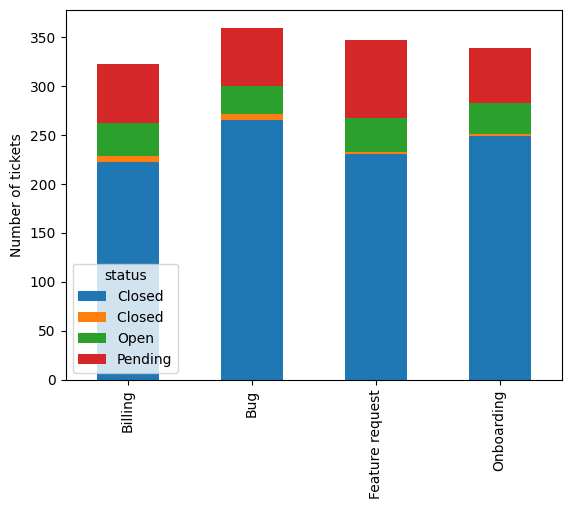

In [ ]:
tickets_status.plot(kind="bar", stacked=True)
plt.xlabel("")
plt.ylabel("Number of tickets")
plt.show()

Bugs is the category with the highest number of tickets treated preceeding by Feature requests. The Billing seems to be the lowest one

In [ ]:
tickets_status_with_ratio = tickets_status.copy()

In [ ]:
tickets_status_with_ratio = tickets_status_with_ratio.div(tickets_status_with_ratio.sum(axis=1), axis=0)
display(tickets_status_with_ratio)

status,Closed,Closed,Open,Pending
category,,,,
Billing,0.687307,0.021672,0.102167,0.188854
Bug,0.736111,0.019444,0.077778,0.166667
Feature request,0.665706,0.005764,0.097983,0.230548
Onboarding,0.734513,0.005900,0.094395,0.165192


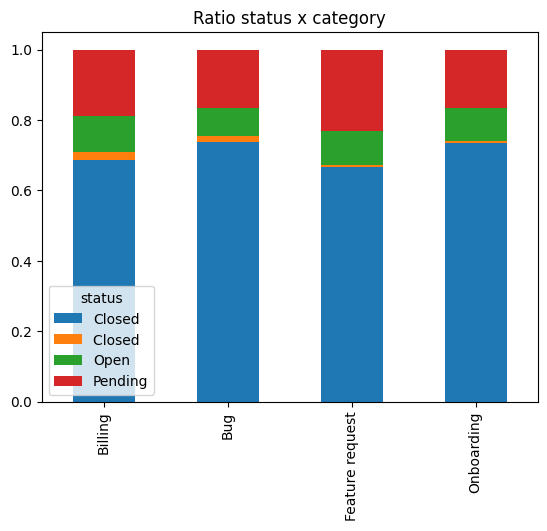

In [ ]:
tickets_status_with_ratio.plot(kind="bar", stacked=True)
plt.xlabel("")
plt.title("Ratio status x category")
plt.show()

More than 60% for all categories have tickets closed. Request for features get the highest pending tickets when onboarding has the lowest. We assume that building features is more difficult than the other categories.

### **Number of tickets per month**

In [ ]:
# Create a pivot table with status, month and number of tickets
tickets_per_month_status = saas_support_tickets.pivot_table(index="status", columns="created_at_month", values="ticket_id", aggfunc="count")

# select only month where number of tickets > 0
tickets_per_month_status = tickets_per_month_status.loc[:, (tickets_per_month_status != 0).any(axis=0)]

/tmp/ipykernel_5625/3696014407.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tickets_per_month_status = saas_support_tickets.pivot_table(index="status", columns="created_at_month", values="ticket_id", aggfunc="count")


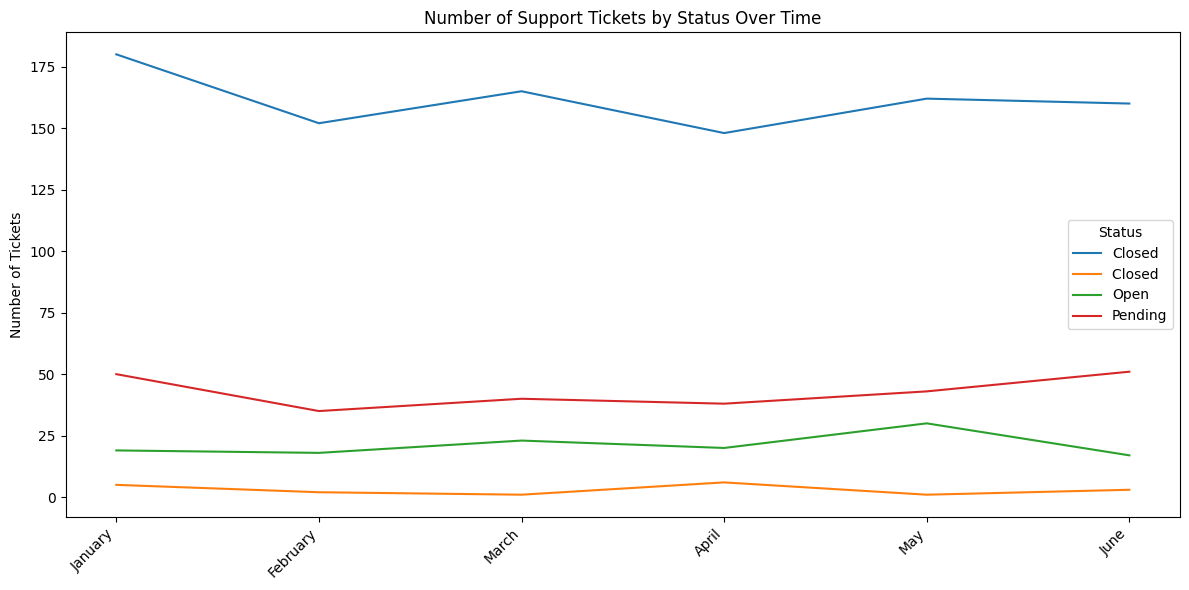

In [ ]:
tickets_per_month_status.T.plot(figsize=(12, 6))
plt.title('Number of Support Tickets by Status Over Time')
plt.xlabel('')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

### **Average score per category**

In [ ]:
category_avg_score = saas_support_tickets.groupby("category", as_index=False).agg(
    avg_csat_score = ("csat_score", "mean")
)

In [ ]:
category_avg_score_srt = category_avg_score.sort_values("avg_csat_score", ascending=False)

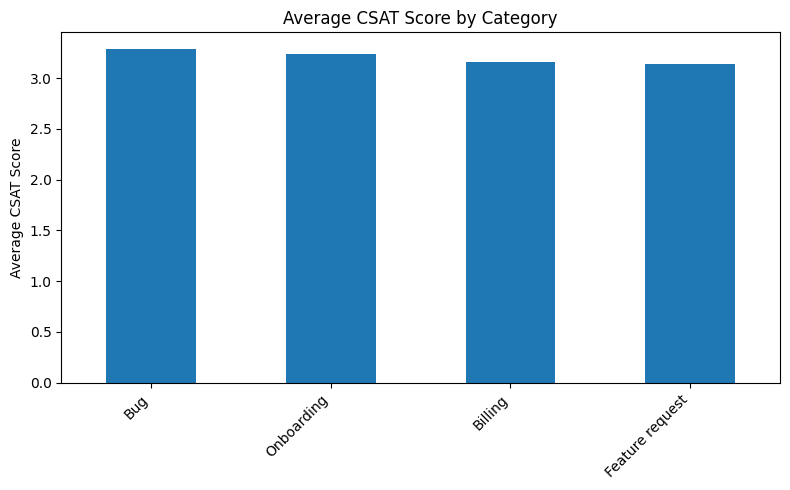

In [ ]:
# Let's build a bar plot to represent how the average score vary across categories
category_avg_score_srt.plot(kind="bar", x="category", y="avg_csat_score", legend=False, figsize=(8, 5))
plt.title('Average CSAT Score by Category')
plt.xlabel('')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Merging and dataset consolidation**

## **Churn labels and account labels**

In [ ]:
account_churn = pd.merge(saas_accounts, saas_churn_labels, on="account_id")
account_churn

,account_id,company_name,industry,company_size,country,acquisition_channel,account_created_at,account_created_at_new,is_small_company,days_since_created,months_since_created,years_since_created,EU vs Non EU,churned
0,1,Company_1,Software,51-200,DE,Outbound,2022-10-12,2022-10-12,False,1354,45,3,EU,False
1,2,Company_2,Manufacturing,201-1000,IT,Inbound,2021-11-23,2021-11-23,False,1677,55,4,EU,False
2,3,Company_3,Retail,11-50,DE,Self-serve,2021-01-16,2021-01-16,True,1988,66,5,EU,True
3,4,Company_4,Software,201-1000,IT,Outbound,2021-07-06,2021-07-06,False,1817,60,5,EU,False
4,5,Company_5,Healthcare,51-200,IT,Self-serve,2023-08-13,2023-08-13,False,1049,34,2,EU,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,494,Company_494,Retail,1-10,US,Self-serve,2023-08-07,2023-08-07,True,1055,35,2,Non EU,False
367,495,Company_495,Finance,51-200,US,Partner,2022-11-03,2022-11-03,False,1332,44,3,Non EU,False
368,496,Company_496,Software,51-200,ES,Self-serve,2022-10-26,2022-10-26,False,1340,44,3,EU,False
369,497,Company_497,Finance,11-50,FR,Partner,2023-02-05,2023-02-05,True,1238,41,3,EU,False


In [ ]:
account_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   account_id              371 non-null    int64         
 1   company_name            371 non-null    object        
 2   industry                371 non-null    object        
 3   company_size            371 non-null    category      
 4   country                 371 non-null    object        
 5   acquisition_channel     371 non-null    object        
 6   account_created_at      371 non-null    object        
 7   account_created_at_new  371 non-null    datetime64[ns]
 8   is_small_company        371 non-null    bool          
 9   days_since_created      371 non-null    int64         
 10  months_since_created    371 non-null    int64         
 11  years_since_created     371 non-null    int64         
 12  EU vs Non EU            371 non-null    object    

In [ ]:
# Let's define some fields as category type in order to display it on a plot
category_fields = ["industry", "acquisition_channel", "company_size"]
for cat in category_fields:
  account_churn[cat] = account_churn[cat].astype("category")

In [ ]:
# Select the data that are from the category type
categorical_cols = account_churn.select_dtypes(["category", "bool"]).columns
categorical_cols_churned = account_churn.groupby("industry", observed=False).agg(
    number_churn = ("churned", "sum")
)

# Exclude 'churned' from the columns argument as it's already the index and value
# Create separate pivot tables for each categorical feature (excluding 'churned')
for col in [c for c in categorical_cols if c != 'churned']:
    print(f"\nChurned customers by {col}:")
    pivot_table = pd.pivot_table(account_churn, index=col, values="churned", aggfunc="sum", observed=False)
    display(pivot_table)



Churned customers by industry:


,churned
industry,
Finance,33
Healthcare,31
Manufacturing,39
Retail,35
Software,21



Churned customers by company_size:


,churned
company_size,
1-10,29
1000+,19
11-50,52
201-1000,19
51-200,40



Churned customers by acquisition_channel:


,churned
acquisition_channel,
Inbound,41
Outbound,36
Partner,42
Self-serve,40



Churned customers by is_small_company:


,churned
is_small_company,
False,78
True,81


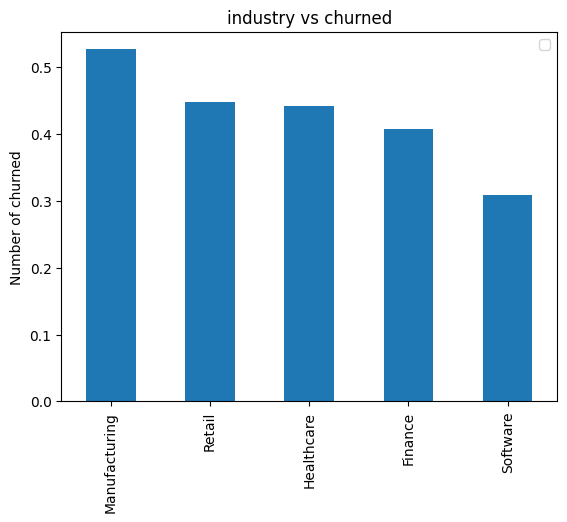

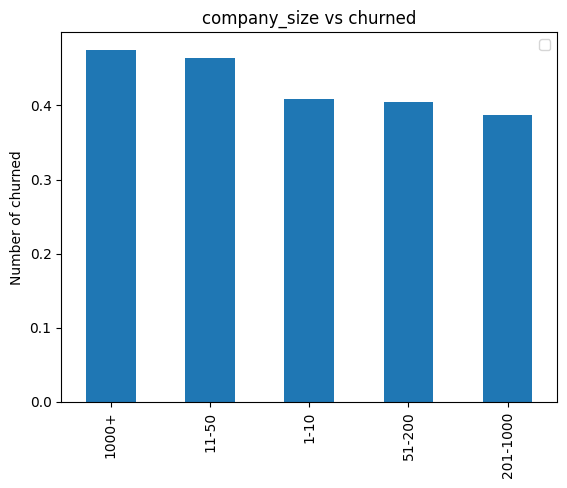

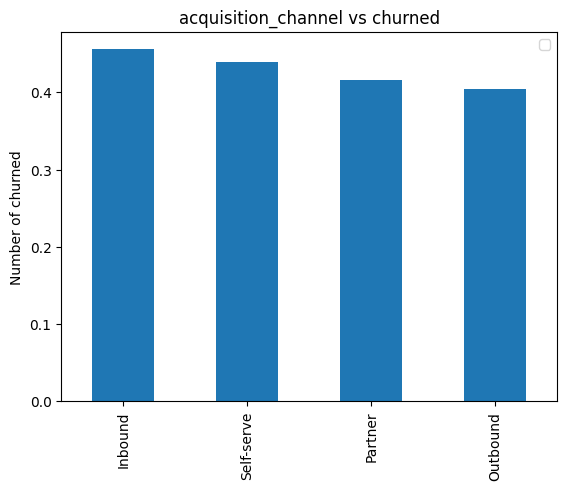

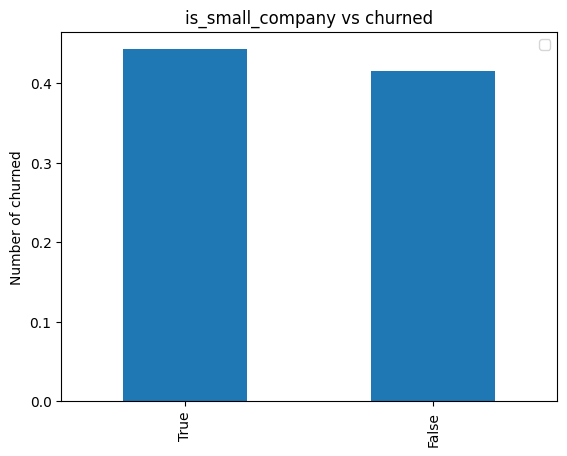

In [ ]:
for col in [c for c in categorical_cols if c != 'churned']:
  account_churn_group = account_churn.groupby(col, observed=False).agg(
      number_churned=("churned", "mean")
  )
  account_churn_group_srt = account_churn_group.sort_values("number_churned", ascending=False)
  account_churn_group_srt.plot(kind="bar", y="number_churned")
  plt.title(f"{col} vs churned")
  plt.xlabel("")
  plt.ylabel("Number of churned")
  plt.legend("")
  plt.show()

The categories that influences more churned are:
- Manufacturing industry
- Self serve and inbound acquisition channel
- 11-50 companies
- No major differences between small and large companies
- EU companies seem to have a slighter advantage

Let's have a general overview on how various categories influence customer to churn

After consolidating data and we can now use this dataset to predict what increase churn risks

We will reduce the dataframe size with features that does have one unique value per row like account_id and company_name

In [ ]:
# Let's drop two useless columns
account_churn_ml_ready = account_churn.drop(columns=["account_id", "company_name", "account_created_at", "account_created_at_new", "country", "company_size", "years_since_created"])

- **Dataframe**: the whole dataframe on which data will be trained
- **Target**: churned / datatype = binary

As the churned datatype is binary, we cannot use a regression but a classification model. Depending on the model, we will need to scale numeric data and encode the string values.

## **Modeling approach**

To evaluate churn prediction performance, I tested several models:

- Logistic Regression
- Random Forest
- XGBoost

Since this is a churn classification task, I focused more on **F1-score, precision, and recall** than on accuracy alone.

This is important because in a churn use case, identifying churning accounts is often more useful than simply maximizing the percentage of correct predictions overall.

Let's also evaluate the data if they are normalized or not, and which metric can fit better

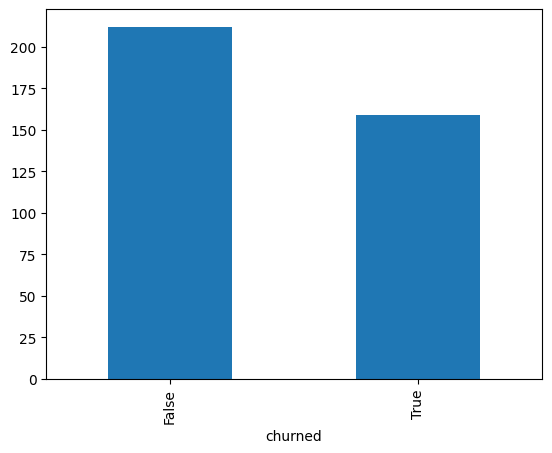

In [ ]:
account_churn["churned"].value_counts().plot(kind="bar")
plt.show()

Both columns are not well distributed, so we will need to use F1-Score, Precision/Recall, or ROC-AUC to avoid having biased results

In [ ]:
# Let's build the X dataframe exluding the target
X_account_churn = account_churn_ml_ready.drop("churned", axis=1)
y_churn = account_churn_ml_ready["churned"]

We can fractionnate the dataset as following: 80% trained and 20% test to evaluate. We will stratify y to have as data churned as not churned to avoid having too much inequalities between the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_account_churn,
                                                    y_churn,
                                                    test_size=0.2,
                                                    stratify=y_churn,
                                                    random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scale_pos_weight = 19

# Identify categorical columns
categorical_cols = X_account_churn.select_dtypes(include=['object', 'bool', 'category']).columns
numeric_cols = X_account_churn.select_dtypes(include=['float', 'int']).columns

# Pipeline for categorical columns
categorical_pipeline = Pipeline([
   ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

# Pipeline for numerical columns
numeric_pipeline = Pipeline([
   ("scaler",  StandardScaler())
])

# Pipeline to join the preprocessor
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# instantiate the models for cv
pipeline_models = {
     'LogisticRegression': Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
          max_iter=1000,
          class_weight='balanced'
        ))
    ]),
   'RandomForestClassifier': Pipeline([
       ("preprocessor", preprocessor),
       ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
       ))
  ]),
   'XGBClassifier': Pipeline([
       ("preprocessor", preprocessor),
       ("model", XGBClassifier(
        n_estimators=120,
        learning_rate = 0.1,
        scale_pos_weight=scale_pos_weight, # Critical for imbalanced data
        random_state=42,
        subsample=0.8 # Introduces randomness (Stochastic GBM)
      ))
   ])
}

Once we have encoded the non numerical values, we will now use a serie of models and find the most accurate one

### **How to predict the churn label depending on other criterias ?**

Let's evalute the score for each model

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cvs_scores_f1 = {}

for name, pipeline in pipeline_models.items():

  # Evaluate the scores
  scores = cross_val_score(pipeline, X_account_churn, y_churn, cv=5, scoring='f1', n_jobs=-1)
  cvs_scores_f1[name] = {'mean f1': np.mean(scores), 'std f1': np.std(scores)}

cvs_scores_f1_df = pd.DataFrame.from_dict(cvs_scores_f1, orient='index')
cvs_scores_f1_df

,mean f1,std f1
LogisticRegression,0.468428,0.045494
RandomForestClassifier,0.384444,0.040765
XGBClassifier,0.557019,0.027083


The best model seems to be XGBClassifier with a f1 score > 0.5

In [ ]:
# Let's take the best model thanks to max
best_model = max(cvs_scores_f1_df["mean f1"].index)
pipeline_best_model = pipeline_models[best_model]
model = pipeline_models[best_model].named_steps["model"]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=120,
              n_jobs=None, num_parallel_tree=None, ...)

### **Xgboost**

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# we can use
pipeline_best_model.fit(X_train, y_train)
y_pred = pipeline_best_model.predict(X_test)

results_model = calculate_metrics(y_test, y_pred, model)
results_model

Results for the model XGBClassifier -
        - F1-score: 0.4941,
        - Precision: 0.3962,
        - Recall: 0.6562,
        - Accuracy: 0.4267
        


{'XGBClassifier': {'f1': 0.49411764705882355,
  'precision': 0.39622641509433965,
  'recall': 0.65625,
  'accuracy': 0.4266666666666667}}

### **All results**

In [ ]:
# get feature importances from the XGBoost model
feature_importances = model.feature_importances_

# Get feature names after preprocessing from the fitted pipeline
feature_names = pipeline_best_model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

list_features = importance_df[importance_df["Importance"] > 0.08]["Feature"]

The features that seem to get the highest importance in the model prediction are acquisition

In [ ]:
# Retrieve the values from the pipeline
X_account_churn_transformed = pipeline_best_model.named_steps['preprocessor'].transform(X_account_churn)

# Recreate a dataframe
X_account_churn_transformed_df = pd.DataFrame(X_account_churn_transformed, columns=feature_names)

# Select features on the dataframe
X_account_churn_encoded_with_features = X_account_churn_transformed_df.loc[:, list_features]
X_account_churn_encoded_with_features

,num__days_since_created,num__months_since_created,cat__acquisition_channel_Inbound,cat__acquisition_channel_Self-serve,cat__EU vs Non EU_EU
0,-0.331129,-0.295498,0.0,0.0,1.0
1,0.736327,0.692835,1.0,0.0,1.0
2,1.764125,1.780001,0.0,1.0,1.0
3,1.199001,1.187001,0.0,0.0,1.0
4,-1.339098,-1.382664,0.0,1.0,1.0
...,...,...,...,...,...
366,-1.319269,-1.283831,0.0,1.0,0.0
367,-0.403835,-0.394331,0.0,0.0,0.0
368,-0.377397,-0.394331,0.0,1.0,1.0
369,-0.714488,-0.690831,0.0,0.0,1.0


The best features that influence customers to churn are:
- the time period between the moment the subscrition occured and the current date.
- the location: EU vs Non EU
- the self-serve and inbound channel

Let's try new training with just the new dataset

In [ ]:
# On réentraine le modèle avec les nouvelles features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_account_churn_encoded_with_features, y_churn,
    random_state=42,
    stratify=y_churn
)

In [ ]:
model.fit(X_train_new, y_train_new)
y_pred_new = model.predict(X_test_new)

results_model_new = calculate_metrics(y_test_new, y_pred_new, model)
results_model_new

Results for the model XGBClassifier -
        - F1-score: 0.5607,
        - Precision: 0.4478,
        - Recall: 0.7500,
        - Accuracy: 0.4946
        


{'XGBClassifier': {'f1': 0.5607476635514018,
  'precision': 0.44776119402985076,
  'recall': 0.75,
  'accuracy': 0.4946236559139785}}

In [ ]:
# We create a new dict to put both results from the same model
comparison_results = {
    'XGBoost (all features)': results_model['XGBClassifier'],
    'XGBoost (selected features)': results_model_new["XGBClassifier"]
}

comparison_results_df = pd.DataFrame.from_dict(comparison_results, orient='index')
comparison_results_df

,f1,precision,recall,accuracy
XGBoost (all features),0.494118,0.396226,0.65625,0.426667
XGBoost (selected features),0.560748,0.447761,0.75000,0.494624


## **What I learned from this project**

This project was especially useful because it felt closer to what a real data analyst might do in a company setting.

Instead of working on one already-clean table, I had to think about:
- how to clean different sources,
- how to merge them correctly,
- which features made sense for churn,
- and how to explain the results clearly.

For me, this project was a good way to practice not only Python and modeling, but also the business reasoning behind a churn use case.

## **Final takeaways**

- XGBoost delivered the strongest results among the tested models.
- A more focused feature set improved performance compared with using all available variables.
- The project shows that model performance depends not only on the algorithm, but also on data preparation, analytical granularity, and feature design.
- In a real company setting, the next step would be to use this type of model to prioritize retention actions for accounts with higher churn risk.